# CO2Dot calibration run (multi-device, LI-6800)

Generates the dataset for refitting the two-state indicator model: end-member channel
vectors E0/E1, per-device scale, alpha_ref(a_w), dH(a_w) and the dye time constant.
All logic lives in `co2dot_calib.py`; this notebook only configures and starts it.

**Architecture.** A background *logger* reads the LI-6800 and every CO2Dot at a fixed
cadence and appends one JSON line per cycle to `cycles.jsonl`. The *scheduler* walks the
protocol (RH blocks > T levels > CO2 steps), changes setpoints and phase tags only, and
writes `events.jsonl`. Everything is checkpointed: Ctrl-C stops cleanly and `run.run()`
resumes. `load_run()` turns a run folder into tidy DataFrames.

**Before starting**
1. Devices in the chamber facing the air stream; LI-6800 leaf thermocouple taped to one film.
2. Fresh CO2 cartridge, soda lime, desiccant and humidifier columns checked (30 h run).
3. Device identity = USB serial number (chip MAC). Fill `LABELS` below once per device.
4. Preflight must show a real LED signal (diff ≫ dark) and no saturation on any device.

In [1]:
import time
from datetime import datetime
from pathlib import Path
from co2dot_calib import (connect_dots, apply_settings, preflight, Protocol, Run, LicorLive,
                          MockLicor, mock_dots, load_run, settled_points)

## 1. Devices

In [2]:
LABELS = {                      # device_id (USB serial = MAC) -> bench label; extend as devices are added
    "3C:DC:75:0D:FA:64": "A",
}
dots = connect_dots(labels=LABELS)
settings = apply_settings(dots, gain=5, atime=100, astep=999)     # common settings; use per_device={...} to override
report = preflight(dots, led_ma=10, n=3)

  COM24: CO2Dot v1.0  id=3C:DC:75:0D:FA:64  label=A
1 CO2Dot(s) connected
[A 3C:DC:75:0D:FA:64 COM24] flash 1.30 s  settings {'model': 'AS7341', 'available': True, 'atime': 100, 'astep': 999, 'gain': 5, 'led': 0}
   diff: 415:516  445:4523  480:7747  515:4533  555:5014  590:3935  630:2927  680:2031  ear:7338  nir:367   dark clear 0   noise 515/630 0.06%/0.07%


## 2. LI-6800

In [3]:
from li_mqtt import LI6800
li = LI6800.connect()
print("broker", li.broker)
time.sleep(2)
print({k: li.get(k) for k in ("CO2_s", "CO2_r", "H2O_s", "Tchamber", "Txchg", "Tleaf", "RHcham", "Flow", "Press")})
licor = LicorLive(li)

broker fe80::21c:94ff:fe04:8d5c%7
{'CO2_s': 419.973, 'CO2_r': 416.124, 'H2O_s': 15.6387, 'Tchamber': 25.0018, 'Txchg': 25.8437, 'Tleaf': 20.7465, 'RHcham': 49.80645518828961, 'Flow': 400, 'Press': 101.263}


## 3. Protocol

Edit the grid and timings here. `rh_cap_by_t` is the static condensation guard (RH 75 % only
at 27 and 32 °C); the live guard uses the dew point of the sample air against the exchanger
and board temperatures. `cartridge_life_h` is an assumption: update it from experience.

In [4]:
P = Protocol(
    rh_levels=(30, 45, 60, 75),
    t_levels=(17, 22, 27, 32),
    co2_levels=(0, 150, 300, 400, 500, 700, 1000, 2000),
    rh_cap_by_t={17: 60, 22: 60},
    co2_dwell_s=300, co2_dwell_long_s=600,
    rh_settle_min_s=45 * 60, rh_settle_max_s=90 * 60,
    t_settle_min_s=15 * 60,
    passes=2,
    flow_umol_s=400,
    cartridge_life_h=10,
)
print(P.feasibility_table())
est = P.estimate()
print(f"\n{est['cells']} cells, {est['co2_steps']} CO2 steps, {est['skipped']} skipped;  ~{est['hours']} h total, "
      f"mixer active ~{est['mixer_hours']} h  = {est['cartridges']:.1f} cartridges of {P.cartridge_life_h} h")

T(C) | RH  30%         | RH  45%         | RH  60%         | RH  75%        
  17 | ok   m17.7 b 23 | ok   m12.0 b 35 | ok   m 7.8 b 47 | SKIP m 4.5 b 58
  22 | ok   m18.4 b 24 | ok   m12.5 b 35 | ok   m 8.1 b 47 | SKIP m 4.6 b 59
  27 | ok   m19.0 b 24 | ok   m12.9 b 36 | ok   m 8.4 b 48 | ok   m 4.8 b 59
  32 | ok   m19.7 b 24 | ok   m13.4 b 36 | ok   m 8.7 b 48 | ok   m 5.0 b 60
m = dew-point margin (C), b = RH at the board (+4 C)

14 cells, 224 CO2 steps, 4 skipped;  ~72.3 h total, mixer active ~32.1 h  = 3.2 cartridges of 10 h


## 4. Dry run without hardware (optional, ~2 min)

Validates the schedule, the file format and the loader with mock instruments and a
compressed protocol. Output goes to `co2dot_data/<timestamp>_mock_dryrun`.

In [5]:
# lic = MockLicor(tau_s={"co2": 2, "t": 2, "rh": 2})
# dry = Run(Path("co2dot_data") / (datetime.now().strftime("%Y-%m-%d_%H-%M-%S") + "_mock_dryrun"),
#           mock_dots(2, lic), lic, Protocol.quick(), cadence_s=1.0)
# dry.run()
# cyc, ev, meta = load_run(dry.outdir); print(cyc.shape); print(ev["kind"].value_counts())

## 5. Run

Starts the logger and the scheduler. Ctrl-C (interrupt the kernel) stops cleanly: the chamber is
returned to ambient, the checkpoint is kept. Run the **resume** cell to continue. If the run
returns `'paused'`, the CO2 cartridge is probably empty: replace it and resume.

In [6]:
# RUN_TAG = "calib"
# run = Run(Path("co2dot_data") / (datetime.now().strftime("%Y-%m-%d_%H-%M-%S") + f"_{RUN_TAG}"),
#           dots, licor, P, cadence_s=10.0, led_ma=10,
#           meta_extra={"operator": "", "notes": "devices in chamber facing the air stream; thermocouple on film A"})
# print("run folder:", run.outdir)
# status = run.run()
# print("status:", status)

In [8]:
%run -i resume_calib_2026-10-07.py


86 logged steps match; resuming 2026-10-07_18-11-54_calib at step 105, cycle 6897
2026-10-08T13:41:04  protocol_changed   from_index=105 changes={'co2_zero_tol_ppm': 15.0, 'settle_at_next_co2': True, 'cell_zero_dwell_s': 180.0, 'rh_settle_min_s': 1200, 't_settle_min_s': 600, 'guard_wait_s': 600.0, 'cooldown_dry': True, 'max_dew_c': 20.0}
2026-10-08T13:41:04  logger_started     cadence_s=10.0 devices=1
2026-10-08T13:41:04  run_started        from_index=105 steps=274 estimate={'hours': 59.9, 'mixer_hours': 32.1, 'cartridges': 3.21, 'cells': 14, 'co2_steps': 224, 'skipped': 4}
2026-10-08T13:41:04  cell_skipped       index=105 rh=60 t=32 reason=dew point 23.3 C > max_dew_c 20.0 C
2026-10-08T13:41:04  setpoint           index=114 tair=25.0 rh_air=50.0
2026-10-08T13:41:04  t_reached          index=114 t=25.0 after_s=0 Tchamber=24.9955
2026-10-08T13:41:04  rh_reached         index=114 rh=50.0 after_s=0 RHcham=49.826635166163946
2026-10-08T14:01:05  cell_settled       index=114 rh=50.0 t=25.0 

In [9]:
%run -i extend_calib_2026-10-07.py


  step 274 anchor       T=25.0 RH=50.0 CO2=400.0 dwell=600.0
  step 275 zero         T=25.0 RH=50.0 CO2=0.0 dwell=600.0
  step 276 cell_settle  T=22 RH=75 CO2=None dwell=0.0
  step 277 co2          T=22 RH=75 CO2=0.0 dwell=600.0
  step 278 co2          T=22 RH=75 CO2=162.1 dwell=600.0
  step 279 co2          T=22 RH=75 CO2=295.1 dwell=600.0
  step 280 co2          T=22 RH=75 CO2=409.7 dwell=600.0
  step 281 co2          T=22 RH=75 CO2=472.8 dwell=600.0
  step 282 co2          T=22 RH=75 CO2=696.7 dwell=600.0
  step 283 co2          T=22 RH=75 CO2=985.6 dwell=600.0
  step 284 co2          T=22 RH=75 CO2=1979.5 dwell=600.0
  step 285 cell_settle  T=17 RH=75 CO2=None dwell=0.0
  step 286 co2          T=17 RH=75 CO2=0.0 dwell=600.0
  step 287 co2          T=17 RH=75 CO2=151.7 dwell=600.0
  step 288 co2          T=17 RH=75 CO2=299.2 dwell=600.0
  step 289 co2          T=17 RH=75 CO2=403.7 dwell=600.0
  step 290 co2          T=17 RH=75 CO2=515.3 dwell=600.0
  step 291 co2          T=17 RH=75

In [ ]:
# Resume after Ctrl-C / cartridge swap (same run object -> same folder and checkpoint):
# status = run.run(); print(status)

## 6. Quick look

(13541, 69) cycles x devices; 525 events


,phase_step,label,kind,pass_,t_set,rh_set,co2_set,n,licor_CO2_s,env_T,env_RH,lr_630_515
0,0.0,A,anchor,0.0,25.0,50.0,400.0,12,399.998,26.704,50.312,-0.193
1,1.0,A,zero,0.0,25.0,50.0,0.0,12,5.279,26.697,50.272,-0.211
2,3.0,A,co2,0.0,17.0,30.0,0.0,12,4.837,20.577,30.186,-0.234
3,4.0,A,co2,0.0,17.0,30.0,170.7,13,170.703,20.574,30.077,-0.205
4,5.0,A,co2,0.0,17.0,30.0,315.5,13,315.500,20.567,30.145,-0.186
...,...,...,...,...,...,...,...,...,...,...,...,...
181,269.0,A,co2,1.0,17.0,30.0,522.5,12,522.504,20.372,29.894,-0.136
182,270.0,A,co2,1.0,17.0,30.0,704.1,12,704.102,20.369,29.837,-0.120
183,271.0,A,co2,1.0,17.0,30.0,994.9,13,994.911,20.372,29.781,-0.101
184,272.0,A,co2,1.0,17.0,30.0,1994.1,13,1994.117,20.376,29.722,-0.064


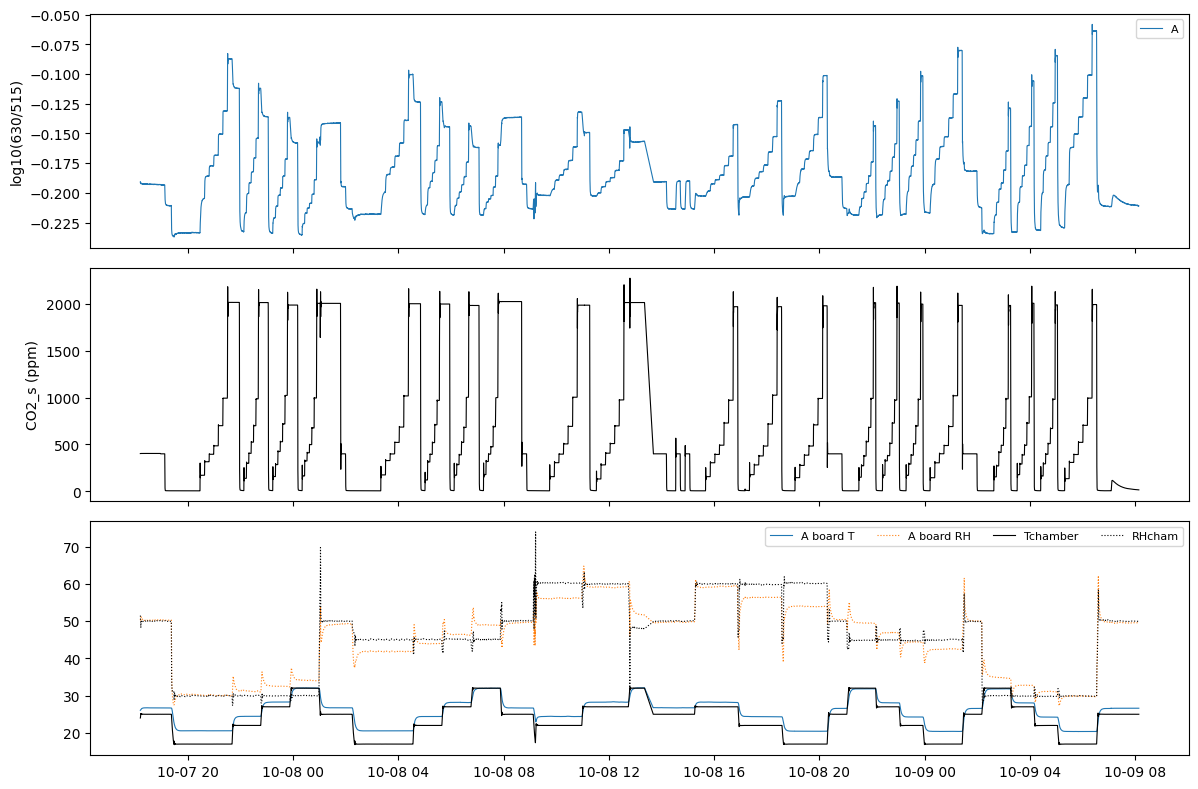

In [10]:
import matplotlib.pyplot as plt
cyc, ev, meta = load_run(run.outdir)
print(cyc.shape, "cycles x devices;", len(ev), "events")
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for lab, g in cyc.groupby("label"):
    ax[0].plot(g["ts"], g["lr_630_515"], lw=0.8, label=lab)
    ax[2].plot(g["ts"], g["env_T"], lw=0.8, label=f"{lab} board T"); ax[2].plot(g["ts"], g["env_RH"], lw=0.8, ls=":", label=f"{lab} board RH")
g0 = cyc.drop_duplicates("cycle")
ax[1].plot(g0["ts"], g0["licor_CO2_s"], "k", lw=0.8); ax[1].set_ylabel("CO2_s (ppm)")
ax[2].plot(g0["ts"], g0["licor_Tchamber"], "k", lw=0.8, label="Tchamber"); ax[2].plot(g0["ts"], g0["licor_RHcham"], "k:", lw=0.8, label="RHcham")
ax[0].set_ylabel("log10(630/515)"); ax[0].legend(ncol=4, fontsize=8); ax[2].legend(ncol=4, fontsize=8)
plt.tight_layout()
sp = settled_points(cyc, last_s=120)
sp[["phase_step", "label", "kind", "pass_", "t_set", "rh_set", "co2_set", "n", "licor_CO2_s", "env_T", "env_RH", "lr_630_515"]].round(3)

## 7. Close

In [11]:
run.close()        # stops the logger (if still running) and closes every CO2Dot port
li.close()

2026-10-09T08:09:12  logger_stopped     cycles=13541
